In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/covid_merged.csv", parse_dates=["date"])
print("Loaded:", df.shape)

Loaded: (221904, 23)


In [2]:
!pip install seaborn

In [4]:
# Resample to weekly to reduce noise
weekly = (
    df.groupby(["country", pd.Grouper(key="date", freq="W")])
    .agg(
        new_cases_7day       = ("new_cases_7day", "mean"),
        cases_per_million    = ("cases_per_million", "mean"),
        new_deaths           = ("new_deaths", "sum"),
        confirmed            = ("confirmed", "max"),
        reproduction_rate    = ("reproduction_rate", "mean"),
        positive_rate        = ("positive_rate", "mean"),
        stringency_index     = ("stringency_index", "mean"),
        total_vaccinations_per_hundred = ("total_vaccinations_per_hundred", "max"),
        population           = ("population", "first"),
        population_density   = ("population_density", "first"),
    )
    .reset_index()
)

# Death rate
weekly["death_rate"] = (
    weekly["new_deaths"] / weekly["new_cases_7day"].replace(0, np.nan)
).clip(upper=1)

# Case growth rate week over week
weekly = weekly.sort_values(["country", "date"])
weekly["case_growth_rate"] = (
    weekly.groupby("country")["new_cases_7day"]
    .pct_change()
    .clip(-1, 5)
)

print(f"Weekly dataset: {weekly.shape}")
weekly.head()

Weekly dataset: (31959, 14)


,country,date,new_cases_7day,cases_per_million,new_deaths,confirmed,reproduction_rate,positive_rate,stringency_index,total_vaccinations_per_hundred,population,population_density,death_rate,case_growth_rate
0,Afghanistan,2020-03-01,0.714286,0.017367,0.0,5,NaN,NaN,27.780000,NaN,41128772.0,54.42,0.00000,NaN
1,Afghanistan,2020-03-08,0.122449,0.002977,0.0,8,NaN,NaN,27.780000,NaN,41128772.0,54.42,0.00000,-0.828571
2,Afghanistan,2020-03-15,0.857143,0.020840,0.0,20,NaN,NaN,30.954286,NaN,41128772.0,54.42,0.00000,5.000000
3,Afghanistan,2020-03-22,2.204082,0.053590,0.0,34,NaN,NaN,40.875714,NaN,41128772.0,54.42,0.00000,1.571429
4,Afghanistan,2020-03-29,7.551020,0.183595,4.0,114,1.51,NaN,57.937143,NaN,41128772.0,54.42,0.52973,2.425926


In [5]:
def compute_risk_score(df_week):
    """
    Composite risk score (0–100) based on:
      - cases_per_million     (40% weight) — current burden
      - case_growth_rate      (25% weight) — trajectory
      - reproduction_rate     (20% weight) — transmission speed
      - positive_rate         (15% weight) — undetected spread
    """
    risk = df_week.copy()

    features = {
        "cases_per_million"  : 0.40,
        "case_growth_rate"   : 0.25,
        "reproduction_rate"  : 0.20,
        "positive_rate"      : 0.15,
    }

    scaler = MinMaxScaler()

    score = np.zeros(len(risk))
    for col, weight in features.items():
        valid = risk[col].notna()
        scaled = np.zeros(len(risk))
        if valid.sum() > 1:
            scaled[valid] = scaler.fit_transform(
                risk.loc[valid, col].values.reshape(-1, 1)
            ).flatten()
        score += scaled * weight

    risk["risk_score"] = (score * 100).round(1)

    # Risk tier
    risk["risk_tier"] = pd.cut(
        risk["risk_score"],
        bins  = [0, 25, 50, 75, 100],
        labels= ["Low", "Moderate", "High", "Critical"]
    )

    return risk

weekly = compute_risk_score(weekly)
print("Risk score computed.")
print(weekly["risk_tier"].value_counts())

Risk score computed.
risk_tier
Low         28319
Moderate      882
High            2
Critical        0
Name: count, dtype: int64


Snapshot date: 2023-03-12
Countries with data: 201



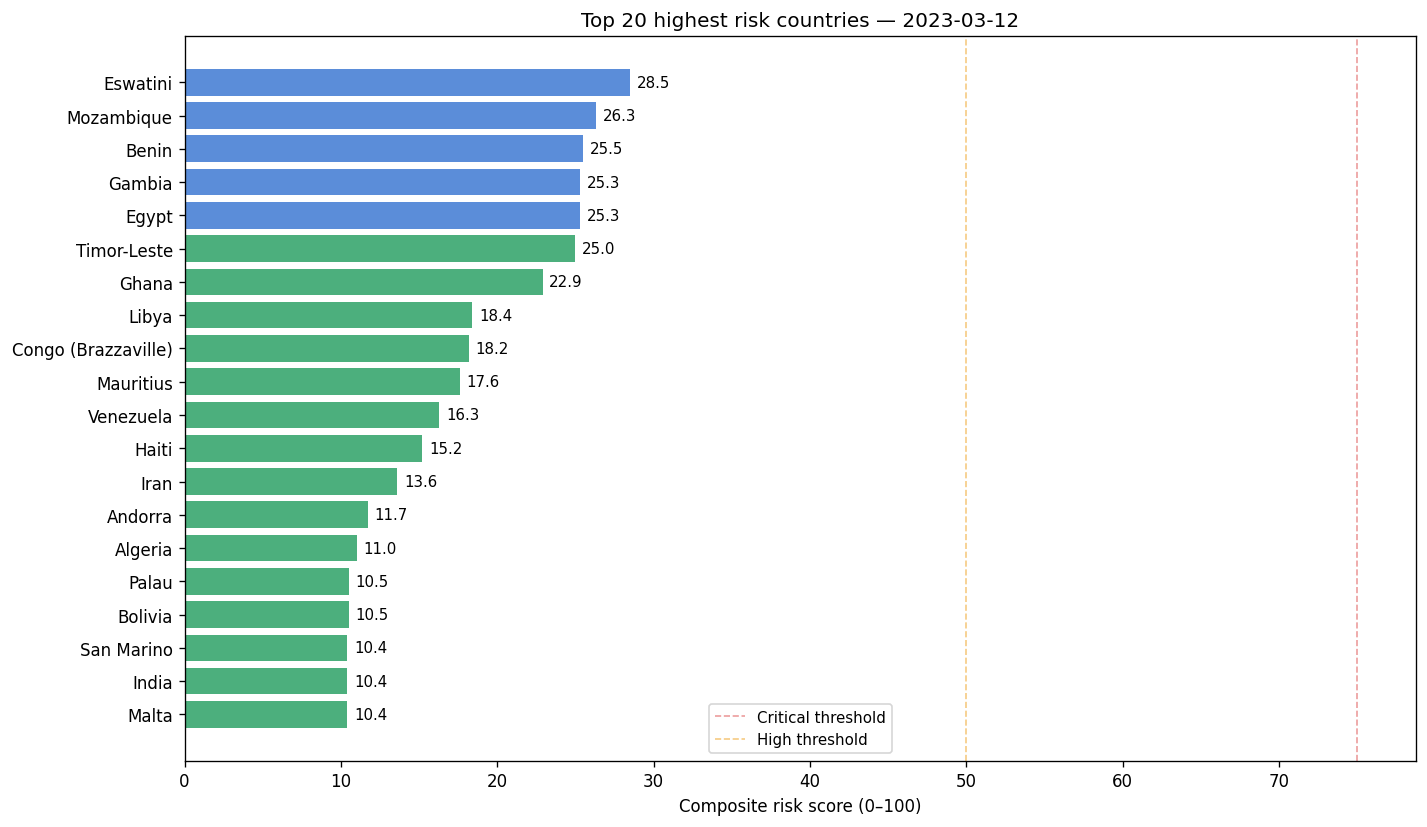

In [6]:
latest_date = weekly["date"].max()
latest = weekly[weekly["date"] == latest_date].copy()
latest = latest.sort_values("risk_score", ascending=False)

print(f"Snapshot date: {latest_date.date()}")
print(f"Countries with data: {latest['risk_score'].notna().sum()}\n")

top20 = latest.dropna(subset=["risk_score"]).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = top20["risk_tier"].map({
    "Critical": "#e05c5c",
    "High"    : "#f0a830",
    "Moderate": "#5b8dd9",
    "Low"     : "#4caf7d"
})
bars = ax.barh(top20["country"][::-1], top20["risk_score"][::-1], color=colors[::-1])
ax.axvline(75, color="#e05c5c", linestyle="--", linewidth=1, alpha=0.6, label="Critical threshold")
ax.axvline(50, color="#f0a830", linestyle="--", linewidth=1, alpha=0.6, label="High threshold")
ax.set_title(f"Top 20 highest risk countries — {latest_date.date()}")
ax.set_xlabel("Composite risk score (0–100)")
ax.bar_label(bars, fmt="{:.1f}", padding=4, fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/top20_risk.png", dpi=120)
plt.show()

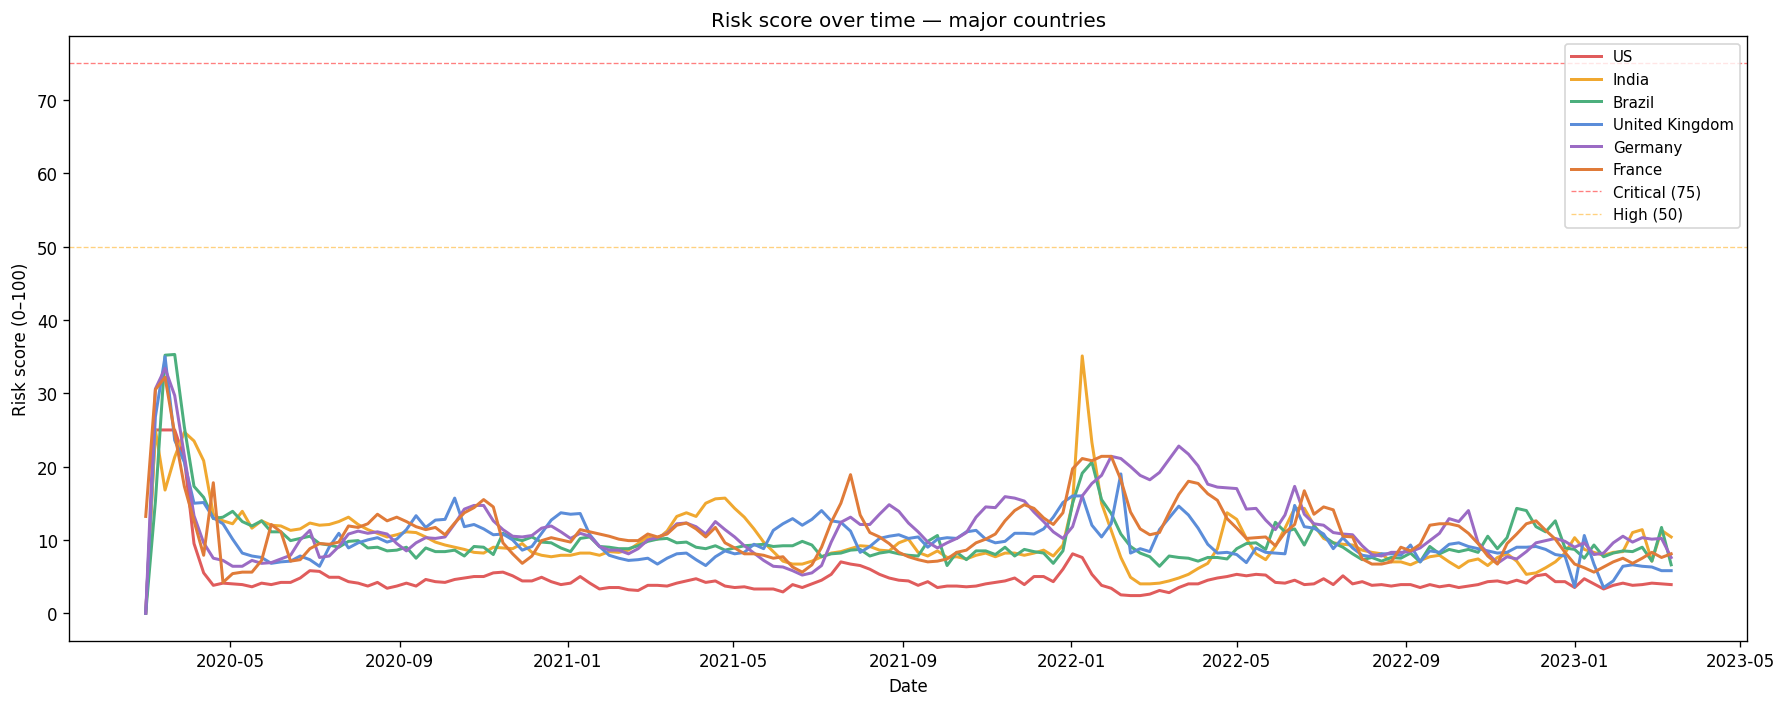

In [7]:
countries = ["US", "India", "Brazil", "United Kingdom", "Germany", "France"]
colors    = ["#e05c5c", "#f0a830", "#4caf7d", "#5b8dd9", "#9b6bc4", "#e07b39"]

fig, ax = plt.subplots(figsize=(15, 6))
for country, color in zip(countries, colors):
    subset = weekly[weekly["country"] == country]
    ax.plot(subset["date"], subset["risk_score"],
            label=country, color=color, linewidth=1.8)

ax.axhline(75, color="red",    linestyle="--", linewidth=0.8, alpha=0.5, label="Critical (75)")
ax.axhline(50, color="orange", linestyle="--", linewidth=0.8, alpha=0.5, label="High (50)")
ax.set_title("Risk score over time — major countries")
ax.set_xlabel("Date")
ax.set_ylabel("Risk score (0–100)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/risk_over_time.png", dpi=120)
plt.show()

In [8]:
def detect_hotspots(weekly_df, growth_threshold=0.5, min_cases=100):
    """
    Flag a country-week as a hotspot if:
      - case growth rate > 50% week over week
      - cases per million > 100
      - reproduction rate > 1.2 (if available)
    """
    hotspots = weekly_df.copy()

    hotspots["is_hotspot"] = (
        (hotspots["case_growth_rate"] > growth_threshold) &
        (hotspots["cases_per_million"] > min_cases) &
        (hotspots["reproduction_rate"].fillna(1.2) > 1.2)
    )

    return hotspots

weekly = detect_hotspots(weekly)

# Show recent hotspots (last 90 days)
recent_cutoff = weekly["date"].max() - pd.Timedelta(days=90)
recent_hotspots = (
    weekly[weekly["is_hotspot"] & (weekly["date"] >= recent_cutoff)]
    [["country", "date", "cases_per_million", "case_growth_rate",
      "reproduction_rate", "risk_score", "risk_tier"]]
    .sort_values("risk_score", ascending=False)
)

print(f"Hotspots detected in last 90 days: {len(recent_hotspots)}")
recent_hotspots.head(20)

Hotspots detected in last 90 days: 2


,country,date,cases_per_million,case_growth_rate,reproduction_rate,risk_score,risk_tier
3485,Bolivia,2022-12-18,130.251083,2.096321,1.847143,21.2,Low
3962,Brazil,2022-12-18,208.056564,0.572445,1.282857,12.6,Low


In [9]:
weekly.to_csv("../data/processed/risk_scores.csv", index=False)

# Also save latest snapshot for the dashboard
latest_snapshot = (
    weekly[weekly["date"] == weekly["date"].max()]
    .dropna(subset=["risk_score"])
    .sort_values("risk_score", ascending=False)
    [["country", "risk_score", "risk_tier", "cases_per_million",
      "case_growth_rate", "reproduction_rate", "positive_rate",
      "total_vaccinations_per_hundred", "population"]]
)
latest_snapshot.to_csv("../data/processed/latest_risk_snapshot.csv", index=False)

print(f"Saved risk_scores.csv         → {weekly.shape}")
print(f"Saved latest_risk_snapshot.csv → {latest_snapshot.shape}")
print("\nRisk tier distribution (latest snapshot):")
print(latest_snapshot["risk_tier"].value_counts())

Saved risk_scores.csv         → (31959, 17)
Saved latest_risk_snapshot.csv → (201, 9)

Risk tier distribution (latest snapshot):
risk_tier
Low         187
Moderate      5
High          0
Critical      0
Name: count, dtype: int64
